# Contact Volume Forecasting — Training & Run Registry

Companion notebook for experimenting with model parameters, holdout window length, lag/rolling window sets, and SARIMA search bounds, **without duplicating any modeling logic**. All training/validation calls go through the `forecasting` package — the same module the Flask dashboard imports — so a run logged here is guaranteed consistent with what the app does.

Each run's parameters and holdout metrics (MAE, RMSE, sMAPE) are logged to the SQLite run registry (`data/registry.db`). Mark a run as **active** per model so the app reads whichever configuration you've designated as current, even while you keep experimenting here.

## 1. Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import display

import config
from forecasting.ingestion import load_series
from forecasting.pipeline import run_holdout_validation, run_forecast, series_stats_snapshot
from forecasting.models import MODEL_NAMES, MODEL_LABELS, BASE_MODEL_NAMES, SALES_MODEL_NAMES
from forecasting.export import publish_forecast_run

print("Setup complete.")

## 2. Configuration

Same style as the original notebook's configuration cell — every tunable lives here as a clearly named variable. Per-model hyperparameter overrides are sparse dicts; omit a model to use its default from `forecasting.models.DEFAULT_PARAMS`.

In [ ]:
MODELS_TO_RUN = MODEL_NAMES  # all 12 (7 base + 5 +Sales)
TEST_SIZE_HOURS = config.TEST_SIZE

PARAM_OVERRIDES = {
    "XGBoost": {
        "n_estimators": 400,
        "learning_rate": 0.02,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 10,
    },
    "LightGBM": {
        "n_estimators": 800,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "min_child_samples": 20,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
    },
    "RandomForest": {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_leaf": 8,
        "max_features": "sqrt",
    },
    "HoltWinters": {
        "trend": "add", "seasonal": "add", "seasonal_periods": 168, "damped_trend": True,
    },
    "Prophet": {
        "weekly_seasonality": True, "daily_seasonality": True, "yearly_seasonality": False,
        "changepoint_prior_scale": 0.05,
    },
    "Ridge": {
        "alpha": 100.0,
    },
    "SeasonalNaive": {
        "weeks": 8,
    },
    # +Sales variants — same base params, sales_lag1w added by pipeline
    "XGBoost+Sales":      {"n_estimators": 400, "learning_rate": 0.02, "max_depth": 4,
                           "subsample": 0.8, "colsample_bytree": 0.7, "min_child_weight": 10},
    "LightGBM+Sales":     {"n_estimators": 800, "learning_rate": 0.02, "num_leaves": 31,
                           "min_child_samples": 20, "subsample": 0.7, "colsample_bytree": 0.7},
    "RandomForest+Sales": {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 8, "max_features": "sqrt"},
    "Ridge+Sales":        {"alpha": 100.0},
    "Prophet+Sales":      {"weekly_seasonality": True, "daily_seasonality": True,
                           "yearly_seasonality": False, "changepoint_prior_scale": 0.05},
}

print(f"Models to run: {MODELS_TO_RUN}")

## 3. Load Data

In [ ]:
series = load_series()
print(f"Series shape : {series.shape}")
print(f"Date range   : {series.index.min()} -> {series.index.max()}")
data_as_of = series.index.max()

## 3b. Load Sales Data (for +Sales models)

In [ ]:
"""
Load weekly ring sell-through (actuals + forecast) from the Historical Sales sheet.
Row 0 = dates, row 2 = Actual/Forecast flag, row 24 = M7 total sell-through.
Actuals and forecast are combined into a single series so the pipeline can
use forecast values as future regressor values during the horizon.
"""
from forecasting.ingestion import get_client
from gspread_dataframe import get_as_dataframe

_client = get_client()
_ss = _client.open_by_url(config.SOURCE_URL)
_ws = _ss.worksheet("Historical Sales")
_raw = get_as_dataframe(_ws, evaluate_formulas=True, header=None).dropna(how="all")

_dates = pd.to_datetime(_raw.iloc[0, 4:], errors="coerce")
_flags = _raw.iloc[2, 4:]
_vals  = pd.to_numeric(_raw.iloc[24, 4:], errors="coerce")
_valid = _dates.notna() & _vals.notna()

_df = pd.DataFrame({
    "date": _dates[_valid].values,
    "flag": _flags[_valid].values,
    "val":  _vals[_valid].values,
}).sort_values("date")

# Combine actuals + forecast into one series (forecast fills the horizon)
sales = pd.Series(_df["val"].values, index=pd.DatetimeIndex(_df["date"].values))
sales.index = sales.index.normalize()  # ensure midnight Monday alignment

print(f"Sales series: {len(sales)} weeks, {sales.index.min().date()} → {sales.index.max().date()}")
print(f"  Actuals  : {(_df['flag']=='Actual').sum()} weeks")
print(f"  Forecast : {(_df['flag']=='Forecast').sum()} weeks")

## 4. Run Holdout Validation

Calls `forecasting.pipeline.run_holdout_validation` — the exact same function the Flask app would call if it ever needed to recompute validation metrics live (in practice the app only reads logged metrics from the registry).

In [ ]:
result = run_holdout_validation(
    series,
    model_names=MODELS_TO_RUN,
    test_size=TEST_SIZE_HOURS,
    params_by_model=PARAM_OVERRIDES,
    sales=sales,
)
display(result.metrics_df)

## 5. Inspect Holdout Metrics

In [ ]:
stats_snapshot = series_stats_snapshot(series)
print("Series stats snapshot:", stats_snapshot)

# Build metrics_by_model for export to _meta sheet
metrics_by_model = {}
for _, row in result.metrics_df.iterrows():
    model_key = next((k for k, v in MODEL_LABELS.items() if v == row["Model"]), None)
    if model_key:
        metrics_by_model[model_key] = {
            "mae":         row["MAE"],
            "rmse":        row["RMSE"],
            "smape":       row["sMAPE"],
            "mape":        row["MAPE"],
            "mape_weekly": row["MAPE_weekly"] if "MAPE_weekly" in row.index else None,
        }

print(f"Metrics captured for {len(metrics_by_model)} models.")
if "MAPE_weekly" not in result.metrics_df.columns:
    print("WARNING: MAPE_weekly not in results — restart the kernel and re-run from cell 1.")

## 8. (Optional) Sanity-check a Forward Forecast

Same `forecasting.pipeline.run_forecast` the app calls, useful for visually confirming a newly tuned model's forward forecast looks reasonable before promoting it to active.

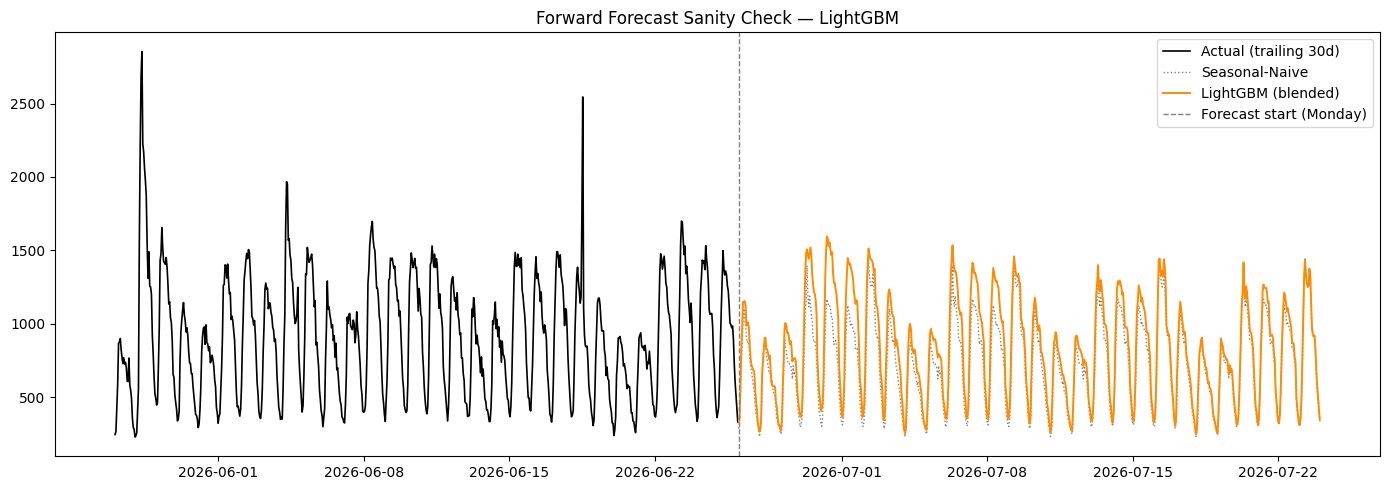

In [8]:
from forecasting.pipeline import run_forecast
import matplotlib.pyplot as plt

CHECK_MODEL = "LightGBM"
CHECK_HORIZON_WEEKS = 4

fc = run_forecast(series, CHECK_MODEL, CHECK_HORIZON_WEEKS * 168, params=PARAM_OVERRIDES.get(CHECK_MODEL))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fc.history_tail.index, fc.history_tail.values, color="black", linewidth=1.2, label="Actual (trailing 30d)")
ax.plot(fc.naive_baseline.index, fc.naive_baseline.values, color="gray", linestyle=":", linewidth=1, label="Seasonal-Naive")
ax.plot(fc.blended.index, fc.blended.values, color="darkorange", linewidth=1.4, label=f"{CHECK_MODEL} (blended)")
ax.axvline(fc.forecast_start, color="gray", linestyle="--", linewidth=1, label="Forecast start (Monday)")
ax.legend()
ax.set_title(f"Forward Forecast Sanity Check — {CHECK_MODEL}")
plt.tight_layout()
plt.show()

## 9. Publish Forecast to Google Sheets

Runs a **3-month forward forecast for every active model** at hourly resolution, then publishes the result to the forecast spreadsheet as a timestamped worksheet (`Forecast_YYYYMMDD_HHMMSS`).

The worksheet contains three horizontal blocks — hourly, daily, weekly — with one column per model, matching the layout the Flask app reads.  A `_meta` worksheet in the same spreadsheet is updated with the run timestamp and horizon so the app knows which sheet is latest.

After running this cell the dashboard will pick up the new forecast within 15 minutes (TTL refresh), or immediately if you click **Refresh Data**.

In [ ]:
HORIZON_HOURS = config.FORECAST_HORIZON_HOURS
print(f"Forecasting {HORIZON_HOURS}h ({HORIZON_HOURS/168:.1f} weeks) for {len(MODELS_TO_RUN)} models...\n")

forecasts = {}
for model_name in MODELS_TO_RUN:
    from forecasting.models import MODEL_KIND
    kind = MODEL_KIND[model_name]
    needs_sales = kind.endswith("_sales")
    print(f"  [{model_name}] running...", end=" ", flush=True)
    try:
        fc = run_forecast(
            series,
            model_name,
            HORIZON_HOURS,
            params=PARAM_OVERRIDES.get(model_name),
            sales=sales if needs_sales else None,
        )
        forecasts[model_name] = fc.blended
        print(f"done — {fc.blended.index[0].date()} → {fc.blended.index[-1].date()}")
    except Exception as e:
        print(f"FAILED: {e}")

print()
sheet_name = publish_forecast_run(forecasts, data_as_of, metrics_by_model=metrics_by_model)
print(f"\nPublished → worksheet '{sheet_name}'")
print(f"Dashboard picks this up within {config.FORECAST_POLL_MINUTES} min (or click Refresh Data).")